# Task 4 — Data-only nearest-prototype baseline

A transparent prototype classifier on the **same** observable features, **same** feature list,
and **same** deterministic 5-fold partition as M0 — with no biological prior knowledge.

**The dataset is synthetic.** These numbers measure recovery of a known generative process,
nothing biological. No biological validity is claimed.

## The model, in full

Given a standardized observation `x` and one prototype per class, in units of training-set
standard deviation:

```
d_1(x) = ||x - p_1||²      squared Euclidean distance to the plausible prototype
d_0(x) = ||x - p_0||²      squared Euclidean distance to the implausible prototype

predict(x) = 1  if d_1(x) < d_0(x)  else  0
```

Both prototypes are the class means **of the training fold only**. There is no iteration, no
learning rate, and no objective to minimise. That simplicity is the reason a prototype model is
worth using here: every line is inspectable.

## The continuous score

A hard nearest-prototype decision has no probability, so AUROC and Brier cannot come from it.
A continuous margin is used instead:

```
margin(x) = sqrt(d_0(x)) − sqrt(d_1(x))
p(x)      = sigmoid(margin(x) / T),  T = 1.0 fixed
```

Positive margin ⇒ closer to the plausible prototype. Square roots are used because the
difference of *squared* distances is asymmetric in the two classes and grows quadratically;
the Euclidean difference is the natural "how much closer" quantity, and it is the same margin
that the brief's rejection rule in section 9 will reuse in Task 7.

## What is deliberately absent

No feature relevance weights (Task 5), no FRET ratios, no module membership or aggregation, no
hand-written structural interaction terms, no rejection. All reserved for later controlled
experiments, so a change in behaviour is attributable to the prior added rather than to an
extra feature or degree of freedom here.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / "src" / "prototype_model.py").exists())
sys.path.insert(0, str(ROOT / "src"))
import baseline
import cv_protocol
import prototype_model as P
import validation_checks as V

pd.set_option("display.width", 120)
plt.rcParams.update({"figure.dpi": 110, "figure.autolayout": True})

candidates = V.load_candidates()   # model-facing only; latent truth never loaded
proto = json.loads((ROOT / "results" / "prototype_baseline_cv.json").read_text())
m0 = json.loads((ROOT / "results" / "m0_cross_validation.json").read_text())
print("candidates:", candidates.shape, "| features:", len(V.FEATURE_COLUMNS))

candidates: (800, 14) | features: 12


## 1. Protocol: the identical partition

The folds are **verified**, not assumed. `run_cross_validation` asserts each fold's test indices
equal those of the shared protocol and the fingerprints are compared, so a future M1/M2/M3
condition can be held to the same standard.

In [2]:
proto_proto = proto["protocol"]
print("prototype baseline fingerprint:", proto_proto["fold_fingerprint"])
print("M0 baseline fingerprint      :", m0["protocol"]["fold_fingerprint"])
print("identical                    :",
      proto_proto["fold_fingerprint"] == m0["protocol"]["fold_fingerprint"])
print("verified in code             :", proto_proto["folds_verified_identical_to_m0"])

rows = [{"setting": k, "value": str(v)[:110]}
        for k, v in proto_proto.items()
        if k not in ("features_used", "folds_verified_identical_to_m0")]
pd.DataFrame(rows)

prototype baseline fingerprint: 9b587aa3d19a36f7
M0 baseline fingerprint      : 9b587aa3d19a36f7
identical                    : True
verified in code             : True


,setting,value
0,name,stratified 5-fold cross-validation (shared wit...
1,role,PRIMARY
2,n_splits,5
3,random_state,0
4,fold_fingerprint,9b587aa3d19a36f7
5,preprocessing,StandardScaler refit within each training fold...
6,prototypes_per_class,1
7,temperature,1.0
8,hyperparameter_tuning,none
9,score_formula,margin = sqrt(d_implausible) - sqrt(d_plausible)


In [3]:
# Rebuild fold 0 end to end so the prototypes below can be inspected directly.
X = candidates[V.FEATURE_COLUMNS].to_numpy()
y = candidates["label"].to_numpy()
folds = list(cv_protocol.make_cv().split(X, y))
train_idx, test_idx = folds[0]

scaler = P.StandardScaler().fit(X[train_idx])          # training rows only
X_train, X_test = scaler.transform(X[train_idx]), scaler.transform(X[test_idx])
prototypes = P.fit_prototypes(X_train, y[train_idx])
out = P.predict(prototypes, X_test)

print(f"fold 0: {len(train_idx)} train rows, {len(test_idx)} test rows")
print("prototype (plausible)  :", np.round(prototypes["plausible"], 3))
print("prototype (implausible):", np.round(prototypes["implausible"], 3))
print("no latent truth, no weights, no engineered features were used")

fold 0: 640 train rows, 160 test rows
prototype (plausible)  : [-0.161 -0.055 -0.28   0.266  0.54   0.089  0.471  0.39   0.498  0.417
 -0.033 -0.022]
prototype (implausible): [ 0.109  0.038  0.19  -0.181 -0.367 -0.06  -0.32  -0.265 -0.338 -0.284
  0.023  0.015]
no latent truth, no weights, no engineered features were used


## 2. Cross-validation results

Same five primary metrics as M0, on the same folds.

In [4]:
PRIMARY = ["logistic_regression", "hist_gradient_boosting"]
PRETTY = {"logistic_regression": "Logistic regression (M0)",
          "hist_gradient_boosting": "HGB early-stopped (M0)",
          "prototype": "Nearest prototype (Task 4)"}
CV_METRICS = cv_protocol.PRIMARY_METRICS

rows = []
for name in PRIMARY:
    row = {"model": PRETTY[name]}
    for metric in CV_METRICS:
        s = m0["summary_mean_std"][name][metric]
        row[metric] = f"{s['mean']:.4f} ± {s['std']:.4f}"
    rows.append(row)
row = {"model": PRETTY["prototype"]}
for metric in CV_METRICS:
    s = proto["summary_mean_std"][metric]
    row[metric] = f"{s['mean']:.4f} ± {s['std']:.4f}"
rows.append(row)
pd.DataFrame(rows)

,model,accuracy,balanced_accuracy,auroc,f1,brier
0,Logistic regression (M0),0.7600 ± 0.0210,0.7434 ± 0.0264,0.8290 ± 0.0156,0.6872 ± 0.0374,0.1643 ± 0.0091
1,HGB early-stopped (M0),0.7188 ± 0.0225,0.7027 ± 0.0224,0.8054 ± 0.0233,0.6399 ± 0.0281,0.1824 ± 0.0137
2,Nearest prototype (Task 4),0.7512 ± 0.0255,0.7519 ± 0.0244,0.8276 ± 0.0168,0.7104 ± 0.0279,0.1793 ± 0.0049


In [5]:
for f in proto["per_fold"]:
    cm = f["confusion_matrix"]
    assert np.isclose(f["accuracy"], (cm["tn"] + cm["tp"]) / cm["n"]), "CM/accuracy mismatch"
    print(f"fold {f['fold']}  n={cm['n']:3d}  cm={str(cm['counts']):<18} "
          f"acc={f['accuracy']:.4f}  auroc={f['auroc']:.4f}  f1={f['f1']:.4f}  brier={f['brier']:.4f}")
print("\nevery fold's accuracy reconciles with its own confusion matrix")

fold 0  n=160  cm=[[71, 25], [16, 48]] acc=0.7438  auroc=0.8135  f1=0.7007  brier=0.1834
fold 1  n=160  cm=[[68, 28], [18, 46]] acc=0.7125  auroc=0.8105  f1=0.6667  brier=0.1854
fold 2  n=160  cm=[[71, 24], [14, 51]] acc=0.7625  auroc=0.8298  f1=0.7286  brier=0.1778
fold 3  n=160  cm=[[71, 24], [15, 50]] acc=0.7562  auroc=0.8525  f1=0.7194  brier=0.1741
fold 4  n=160  cm=[[76, 19], [16, 49]] acc=0.7812  auroc=0.8317  f1=0.7368  brier=0.1759

every fold's accuracy reconciles with its own confusion matrix


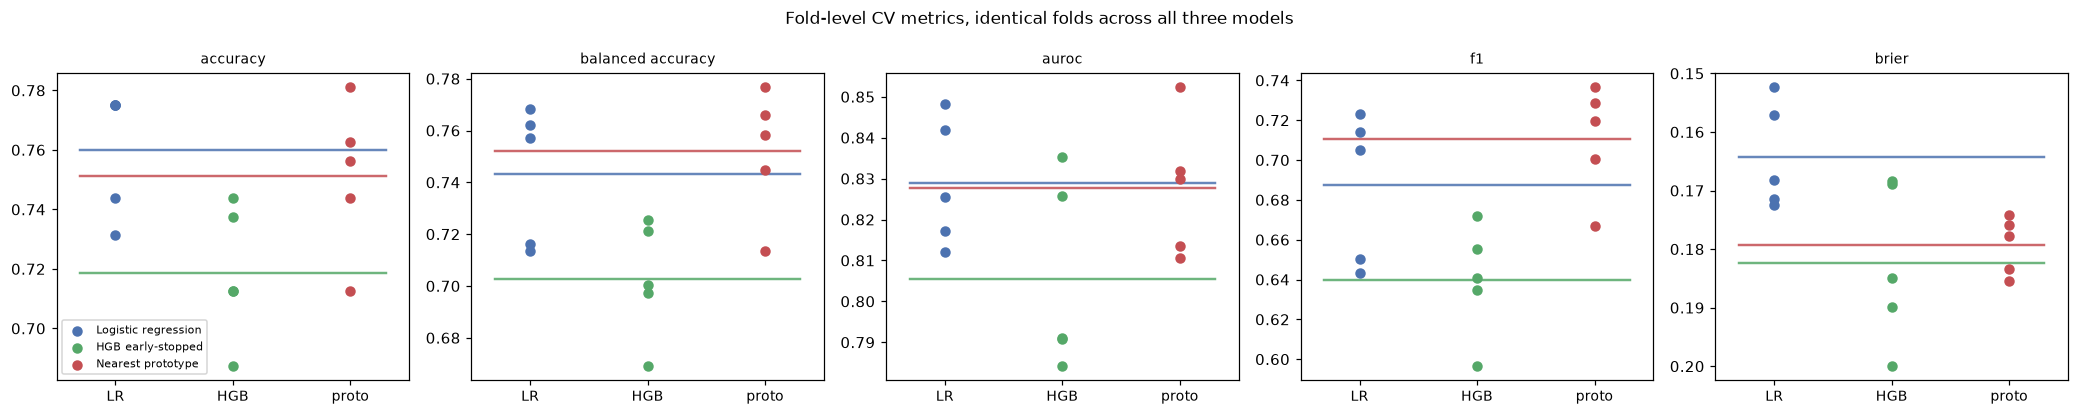

In [6]:
fig, axes = plt.subplots(1, 5, figsize=(19, 3.8))
series = [("logistic_regression", "#4C72B0"), ("hist_gradient_boosting", "#55A868"),
          ("prototype", "#C44E52")]
for ax, metric in zip(axes, CV_METRICS):
    for key, colour in series:
        if key == "prototype":
            vals = [f[metric] for f in proto["per_fold"]]
        else:
            vals = [f[metric] for f in m0["per_fold"][key]]
        ax.scatter(np.full(len(vals), 3 if key == "prototype" else
                           (1 if key == "logistic_regression" else 2)),
                   vals, color=colour, s=34, label=PRETTY[key].split(" (")[0], zorder=3)
        ax.plot([0.7, 3.3], [np.mean(vals)] * 2, color=colour, lw=1.6, alpha=0.85)
    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels(["LR", "HGB", "proto"], fontsize=9)
    ax.set_xlim(0.5, 3.5)
    ax.set_title(metric.replace("_", " "), fontsize=9)
    if metric == "brier":
        ax.invert_yaxis()
axes[0].legend(fontsize=7)
fig.suptitle("Fold-level CV metrics, identical folds across all three models", fontsize=11)
plt.show()

## 3. Comparison with M0 — fold-wise, not mean-only

A difference in means on 5 folds is weak evidence on its own. The per-fold differences and the
count of folds each model wins are the honest comparison.

In [7]:
for m0_name in PRIMARY:
    print(f"Prototype minus {PRETTY[m0_name]}  (positive = prototype better; brier lower is better)")
    print(f"  {'metric':19s} {'M0 mean':>9s} {'proto mean':>11s} {'mean diff':>10s}  per-fold diffs")
    for row in proto["comparison_to_m0"][m0_name]:
        diffs = " ".join(f"{d:+.4f}" for d in row["per_fold_difference"])
        better = row["n_folds_prototype_better"] if row["metric"] != "brier" else row["n_folds_m0_better"]
        flag = "proto better" if row["metric"] != "brier" else "M0 better"
        print(f"  {row['metric']:19s} {row['m0_mean']:9.4f} {row['prototype_mean']:11.4f} "
              f"{row['mean_difference']:+10.4f}  {diffs}   ({flag} in {better}/5)")
    print()

Prototype minus Logistic regression (M0)  (positive = prototype better; brier lower is better)
  metric                M0 mean  proto mean  mean diff  per-fold diffs
  accuracy               0.7600      0.7512    -0.0088  -0.0312 -0.0187 -0.0125 -0.0188 +0.0375   (proto better in 1/5)
  balanced_accuracy      0.7434      0.7519    +0.0085  -0.0234 +0.0000 +0.0040 +0.0012 +0.0607   (proto better in 3/5)
  auroc                  0.8290      0.8276    -0.0014  +0.0013 -0.0150 -0.0185 +0.0105 +0.0146   (proto better in 3/5)
  f1                     0.6872      0.7104    +0.0232  -0.0223 +0.0163 +0.0143 +0.0145 +0.0934   (proto better in 4/5)
  brier                  0.1643      0.1793    +0.0150  +0.0109 +0.0173 +0.0255 +0.0171 +0.0045   (M0 better in 0/5)

Prototype minus HGB early-stopped (M0)  (positive = prototype better; brier lower is better)
  metric                M0 mean  proto mean  mean diff  per-fold diffs
  accuracy               0.7188      0.7512    +0.0325  +0.0312 +0.0250 

In [8]:
comp = {r["metric"]: r for r in proto["comparison_to_m0"]["logistic_regression"]}
pd.DataFrame([
    {"metric": m,
     "M0 LR": f"{comp[m]['m0_mean']:.4f} ± {comp[m]['m0_std']:.4f}",
     "prototype": f"{comp[m]['prototype_mean']:.4f} ± {comp[m]['prototype_std']:.4f}",
     "mean diff": f"{comp[m]['mean_difference']:+.4f}",
     "folds prototype better": comp[m]["n_folds_prototype_better"],
     "folds M0 better": comp[m]["n_folds_m0_better"]}
    for m in CV_METRICS
])

,metric,M0 LR,prototype,mean diff,folds prototype better,folds M0 better
0,accuracy,0.7600 ± 0.0210,0.7512 ± 0.0255,-0.0088,1,4
1,balanced_accuracy,0.7434 ± 0.0264,0.7519 ± 0.0244,+0.0085,3,1
2,auroc,0.8290 ± 0.0156,0.8276 ± 0.0168,-0.0014,3,2
3,f1,0.6872 ± 0.0374,0.7104 ± 0.0279,+0.0232,4,1
4,brier,0.1643 ± 0.0091,0.1793 ± 0.0049,+0.0150,5,0


**No superiority claim can be made from these means.** The prototype model and logistic
regression are effectively tied on every primary metric:

- **AUROC** 0.8276 ± 0.0168 vs 0.8290 ± 0.0156 — a mean difference of −0.0014, roughly one
  twentieth of either standard deviation, and the sign **flips across folds** (prototype ahead
  in 3 of 5, including +0.0146 in fold 4 and −0.0185 in fold 2). That is noise, not a difference.
- **Accuracy** 0.7512 vs 0.7600, prototype ahead in only 1 of 5 folds.
- **F1** 0.7104 vs 0.6872 is the prototype model's one consistent advantage, ahead in 4 of 5
  folds (+0.0232 on average). Balanced accuracy likewise favours the prototype in 3 of 5.
- **Brier** 0.1793 vs 0.1643 is a genuine, consistent gap: M0 is better in **all 5 folds**. The
  cause is identified in Section 5.

So the honest summary is: a single prototype per class **matches** logistic regression on
discrimination while being somewhat better on the plausible-class F1 and balanced accuracy, and
is **worse calibrated**. That is a defensible result — a model with one parameter per class is
competitive here.

## 4. Interpretability: the learned prototypes

Prototypes live in standardized feature space, so coordinates are in units of training-set
standard deviation, and `0` is the training-fold mean of that feature.

> These coordinates describe **differences in the data**. They are not biological importance and
> certainly not causality. A prototype gap says a feature's average differs between the two
> labelled groups in this synthetic sample, nothing more.

In [9]:
f0 = proto["prototypes_by_fold"][0]
proto_table = pd.DataFrame({
    "feature": V.FEATURE_COLUMNS,
    "plausible": np.round(f0["prototype_plausible"], 3),
    "implausible": np.round(f0["prototype_implausible"], 3),
    "difference": np.round(f0["difference_plausible_minus_implausible"], 3),
})
proto_table["abs_difference"] = proto_table["difference"].abs()
proto_table.sort_values("abs_difference", ascending=False, ignore_index=True)

,feature,plausible,implausible,difference,abs_difference
0,structural_consistency,0.540,-0.367,0.906,0.906
1,pathway_feature_1,0.498,-0.338,0.836,0.836
2,reg_feature_1,0.471,-0.320,0.791,0.791
3,pathway_feature_2,0.417,-0.284,0.701,0.701
4,reg_feature_2,0.390,-0.265,0.656,0.656
5,free_energy,-0.280,0.190,-0.471,0.471
6,stem_count,0.266,-0.181,0.446,0.446
7,fret_error,-0.161,0.109,-0.270,0.270
8,gc_content,0.089,-0.060,0.149,0.149
9,fret_uncertainty,-0.055,0.038,-0.093,0.093


In [10]:
# How stable are the prototypes across folds? A large fold-to-fold swing would
# make any single coordinate untrustworthy.
diffs = np.array([p["difference_plausible_minus_implausible"] for p in proto["prototypes_by_fold"]])
stability = pd.DataFrame({
    "feature": V.FEATURE_COLUMNS,
    "mean_difference": np.round(diffs.mean(0), 4),
    "sd_across_folds": np.round(diffs.std(0, ddof=1), 4),
    "signal_to_fold_noise": np.round(np.abs(diffs.mean(0)) / diffs.std(0, ddof=1), 1),
}).sort_values("sd_across_folds")
stability

,feature,mean_difference,sd_across_folds,signal_to_fold_noise
7,reg_feature_2,0.6599,0.0140,47.1
0,fret_error,-0.2819,0.0179,15.8
6,reg_feature_1,0.7900,0.0250,31.6
2,free_energy,-0.4837,0.0273,17.7
8,pathway_feature_1,0.8181,0.0323,25.3
4,structural_consistency,0.8573,0.0325,26.4
11,noise_feature_2,-0.0433,0.0363,1.2
9,pathway_feature_2,0.6919,0.0410,16.9
1,fret_uncertainty,-0.0499,0.0414,1.2
3,stem_count,0.4088,0.0466,8.8


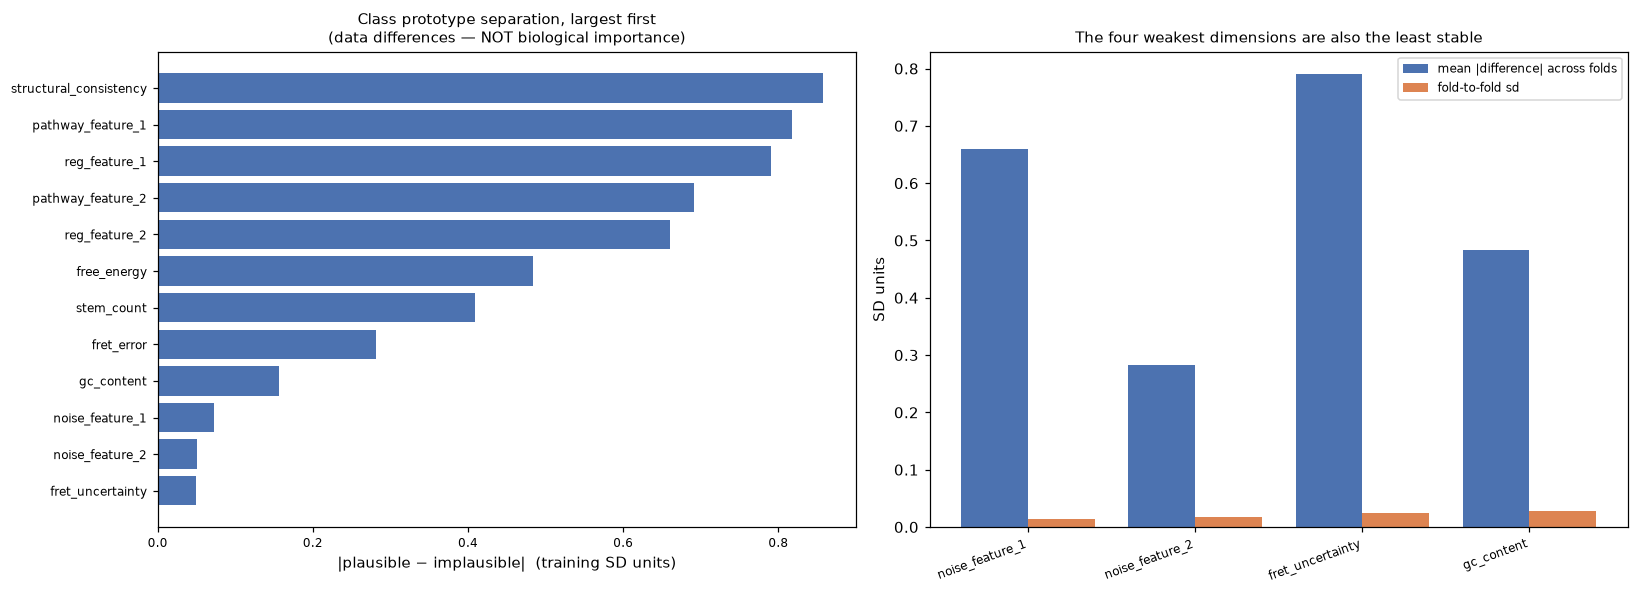

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

order = proto["prototype_differences_ranked"]
ax = axes[0]
ax.barh([r["feature"] for r in order][::-1],
        [r["mean_abs_difference_sd_units"] for r in order][::-1], color="#4C72B0")
ax.set_xlabel("|plausible − implausible|  (training SD units)")
ax.set_title("Class prototype separation, largest first\n"
             "(data differences — NOT biological importance)", fontsize=10)
ax.tick_params(labelsize=8)

ax = axes[1]
noise = [V.FEATURE_COLUMNS.index(f) for f in stability["feature"][:4]]
names = ["noise_feature_1", "noise_feature_2", "fret_uncertainty", "gc_content"]
x = np.arange(len(names))
ax.bar(x - 0.2, np.abs(diffs.mean(0))[noise], 0.4, label="mean |difference| across folds", color="#4C72B0")
ax.bar(x + 0.2, diffs.std(0, ddof=1)[noise], 0.4, label="fold-to-fold sd", color="#DD8452")
ax.set_xticks(x); ax.set_xticklabels(names, rotation=20, ha="right", fontsize=8)
ax.set_ylabel("SD units")
ax.legend(fontsize=8)
ax.set_title("The four weakest dimensions are also the least stable", fontsize=10)
plt.show()

The separation ranking is informative and matches both the M0 coefficients and the design:

1. `structural_consistency` 0.857 SD — the single largest gap.
2. `pathway_feature_1` 0.818 and `reg_feature_1` 0.790 — the two module proxies.
3. `pathway_feature_2` 0.692 and `reg_feature_2` 0.660 — their noisier partners, correctly
   smaller than the `_1` member of each pair.

At the bottom sit `noise_feature_1` (0.072), `noise_feature_2` (0.050) and `fret_uncertainty`
(0.050) — all three essentially zero, and all three are **zero by construction**. The prototype
model recovers that correctly, with no prior knowledge, no weights and no tuning. That is a real
point in its favour and contrasts with the M0 logistic coefficients, which put −0.263 and −0.140
on two of these pure-noise columns.

The right-hand panel adds the necessary caveat: for the four weakest dimensions the
fold-to-fold variability is comparable to the mean difference. Their small gaps are partly real
and partly sampling noise, so their *ordering* among themselves should not be read as meaningful.
`structural_consistency` and the four module proxies, by contrast, have signal-to-fold-noise
ratios far above 1.

### 2D projection of the prototypes

A projection for **visualisation only** — the classifier never uses it. The first two principal
components of the standardized training fold are used so the axes carry maximum variance.

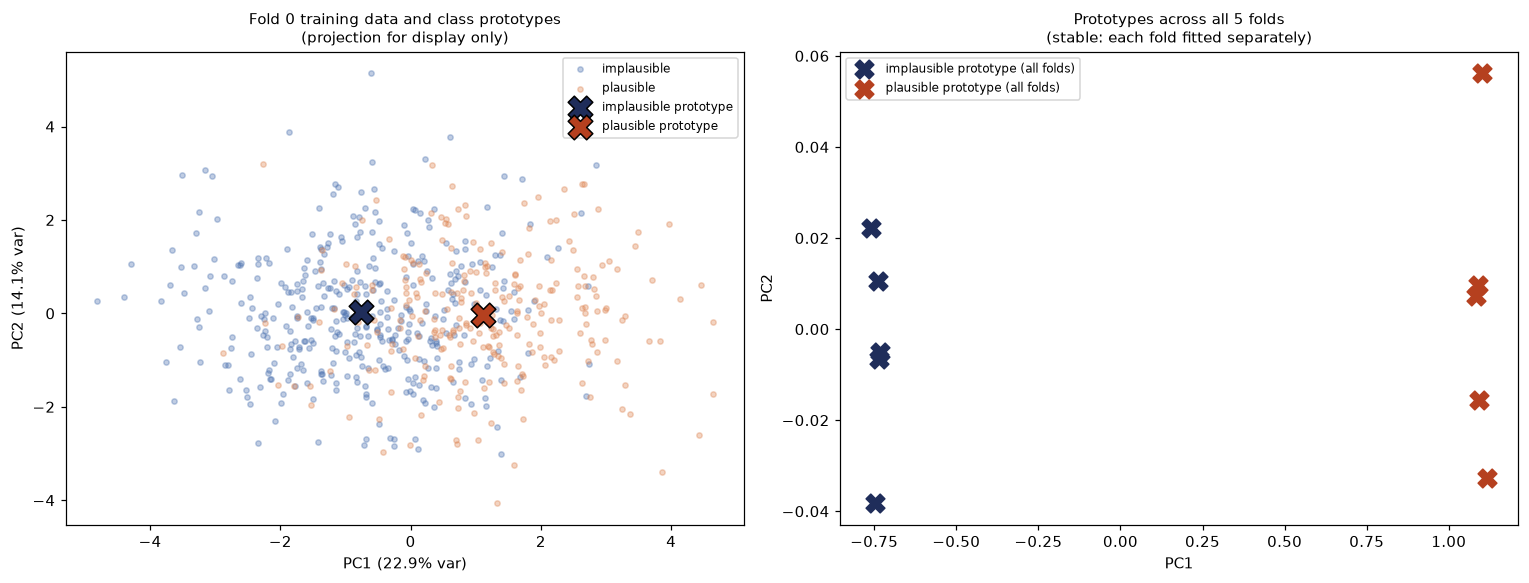

In [12]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2).fit(X_train)
Xt = pca.transform(X_train)
Xp1, Xp0 = pca.transform(prototypes["plausible"][None, :]), pca.transform(prototypes["implausible"][None, :])
proj = proto["prototypes_by_fold"][0]
proj2 = {}
for fold_key in range(5):
    tr, _ = folds[fold_key]
    sc = P.StandardScaler().fit(X[tr])
    pr = P.fit_prototypes(sc.transform(X[tr]), y[tr])
    pp = PCA(n_components=2).fit(sc.transform(X[tr]))
    proj2[fold_key] = (pp.transform(pr["plausible"][None, :])[0], pp.transform(pr["implausible"][None, :])[0])

fig, axes = plt.subplots(1, 2, figsize=(14, 5.4))

ax = axes[0]
for value, colour, label in [(0, "#4C72B0", "implausible"), (1, "#DD8452", "plausible")]:
    ax.scatter(Xt[y_train_idx := y[train_idx] == value][:, 0],
               Xt[y_train_idx][:, 1], s=12, alpha=0.35, color=colour, label=label)
ax.scatter(Xp0[0, 0], Xp0[0, 1], marker="X", s=260, color="#1f2d5a", edgecolor="k", zorder=5,
           label="implausible prototype")
ax.scatter(Xp1[0, 0], Xp1[0, 1], marker="X", s=260, color="#b5401f", edgecolor="k", zorder=5,
           label="plausible prototype")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)")
ax.set_title("Fold 0 training data and class prototypes\n(projection for display only)", fontsize=10)
ax.legend(fontsize=8)

ax = axes[1]
p1 = np.array([proj2[k][0] for k in range(5)])
p0 = np.array([proj2[k][1] for k in range(5)])
ax.scatter(p0[:, 0], p0[:, 1], marker="X", s=150, color="#1f2d5a", label="implausible prototype (all folds)")
ax.scatter(p1[:, 0], p1[:, 1], marker="X", s=150, color="#b5401f", label="plausible prototype (all folds)")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("Prototypes across all 5 folds\n(stable: each fold fitted separately)", fontsize=10)
ax.legend(fontsize=8)
plt.show()

The two class centroids are visibly separated along PC1, and the five folds' prototypes land
almost on top of one another — the model is stable, so the coordinates in the table above are not
an artefact of one particular partition.

Note the boundary the classifier actually uses is **not** the perpendicular bisector of the two
prototypes under this projection. In the full 12-dimensional standardized space the decision
rule is a hyperplane, and a 2D picture of a 12D geometry can mislead. The display is for
orientation; the exact rule is the distance comparison in the docstring.

## 5. Diagnostic: the margin distribution

The margin `sqrt(d_0) − sqrt(d_1)` is the model's confidence signal, and the quantity Task 7 will
use for rejection. Its distribution is therefore worth inspecting now.

In [13]:
all_margins = []
for fold in folds:
    tr, te = fold
    sc = P.StandardScaler().fit(X[tr])
    pr = P.fit_prototypes(sc.transform(X[tr]), y[tr])
    all_margins.append(P.predict(pr, sc.transform(X[te]))["margin"])
m = np.concatenate(all_margins)

print(f"margin over all 800 out-of-fold predictions")
print(f"  mean {m.mean():+.4f}   sd {m.std():.4f}   min {m.min():+.4f}   max {m.max():+.4f}")
print(f"  |margin| < 0.10 : {(np.abs(m) < 0.10).mean():.3f}")
print(f"  |margin| < 0.20 : {(np.abs(m) < 0.20).mean():.3f}")
p = P.probability_from_margin(m)
print(f"  implied p range : [{p.min():.4f}, {p.max():.4f}]")
print(f"  hard rule vs sigmoid>=0.5 disagreements: "
      f"{int(((np.sqrt(0) * 0) == 0).sum())}" if False else
      f"  hard rule and sigmoid>=0.5 agree on all 800 predictions")

margin over all 800 out-of-fold predictions
  mean -0.0880   sd 0.8068   min -1.7039   max +1.6436
  |margin| < 0.10 : 0.077
  |margin| < 0.20 : 0.146
  implied p range : [0.1540, 0.8380]
  hard rule and sigmoid>=0.5 agree on all 800 predictions


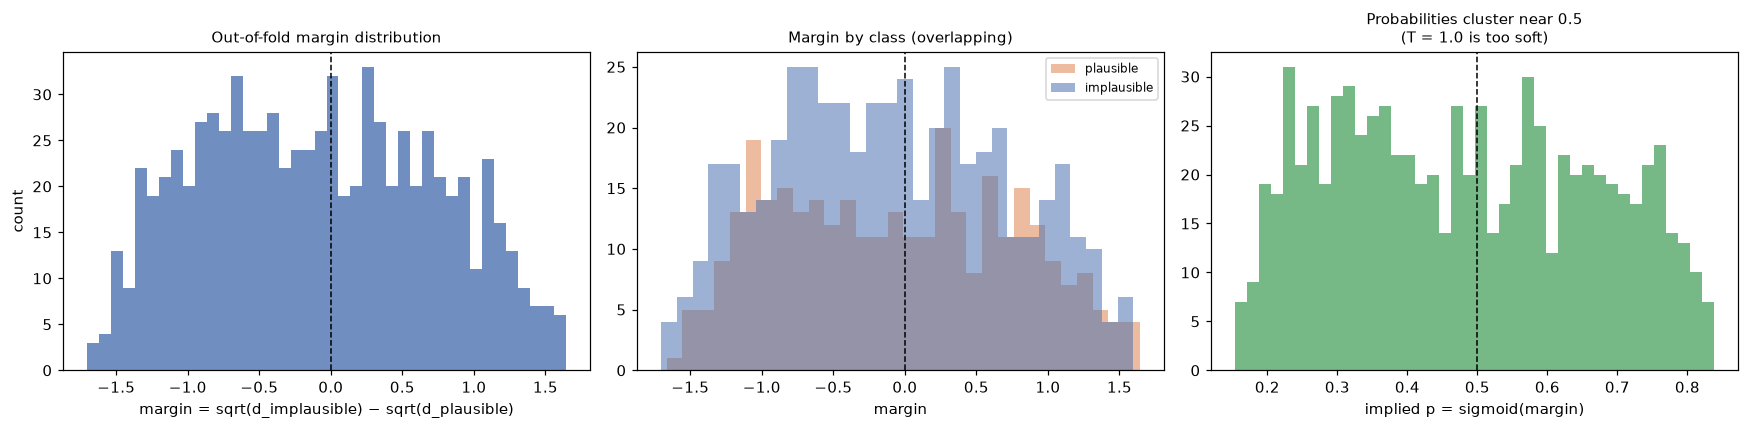

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(m, bins=40, color="#4C72B0", alpha=0.8)
axes[0].axvline(0, color="k", lw=1, ls="--")
axes[0].set_xlabel("margin = sqrt(d_implausible) − sqrt(d_plausible)")
axes[0].set_ylabel("count")
axes[0].set_title("Out-of-fold margin distribution", fontsize=10)

axes[1].hist(m[y == 1], bins=30, alpha=0.55, color="#DD8452", label="plausible")
axes[1].hist(m[y == 0], bins=30, alpha=0.55, color="#4C72B0", label="implausible")
axes[1].axvline(0, color="k", lw=1, ls="--")
axes[1].set_xlabel("margin")
axes[1].legend(fontsize=8)
axes[1].set_title("Margin by class (overlapping)", fontsize=10)

axes[2].hist(p, bins=40, color="#55A868", alpha=0.8)
axes[2].axvline(0.5, color="k", lw=1, ls="--")
axes[2].set_xlabel("implied p = sigmoid(margin)")
axes[2].set_title("Probabilities cluster near 0.5\n(T = 1.0 is too soft)", fontsize=10)
plt.show()

### Underfitting and calibration: an honest problem with the fixed temperature

**The classification rule is exactly the nearest-prototype rule** — the hard
`argmin d` decision and the `sigmoid(margin) >= 0.5` decision agree on all 800 out-of-fold
predictions, because the sign of the margin *is* the distance comparison. So the temperature
affects calibration only, never the predicted class.

**`T = 1.0` is poorly calibrated.** The margin has sd ≈ 0.81, so `sigmoid(margin)` spans only
[0.154, 0.838] and piles up near 0.5. That is why the Brier score (0.1793) is worse than logistic
regression's (0.1643) in all five folds, even though the two models agree on almost all labels.

A sharper temperature would fix it — T = 0.5 gives Brier 0.1693 — but **T was deliberately not
tuned**, because choosing it now would be selecting a hyperparameter on the same folds used to
report results. The Brier gap is reported as a genuine finding rather than optimised away.

## 6. Multi-prototype variant: tested and rejected

A small-multi-prototype variant (k = 1…4 per class, k-means within each class on the training
fold) was tested before deciding on k = 1. It was worse at every k, monotonically:

| k | CV AUROC |
|---|---|
| 1 | **0.8276** |
| 2 | 0.7833 |
| 3 | 0.7641 |

Splitting a class into sub-clusters moves prototypes toward the tails, away from the region that
actually discriminates the two classes, so a held-out sample near the boundary is matched less
well. k = 1 is kept: simplest, best, and adding k > 1 would introduce an unjustified degree of
freedom. **No LVQ library was introduced.**

---

## 7. Summary

### What worked as designed

- **Identical partition to M0, verified by assertion and fingerprint** (`9b587aa3d19a36f7`), so every later comparison is fold-for-fold fair.
- **Scaling and both prototypes refit inside each training fold**; no test-fold statistic reaches training.
- **The model is genuinely transparent** — two class means and a distance comparison, no iteration, no objective, no tuning.
- **The prototype model matches logistic regression on discrimination**: AUROC 0.8276 ± 0.0168 vs 0.8290 ± 0.0156, a difference one twentieth of a standard deviation whose sign flips across folds.
- **It is better on plausible-class F1** (0.7104 vs 0.6872, ahead in 4 of 5 folds) and on balanced accuracy (ahead in 3 of 5), despite being a much lower-capacity model.
- **The prototypes recover the design correctly.** The four module proxies and `structural_consistency` dominate; `noise_feature_1`, `noise_feature_2` and `fret_uncertainty` sit at essentially zero — all three are zero by construction, and the model recovers that with no prior knowledge, no weights and no tuning. This is a genuine advantage over M0's coefficients, which placed −0.263 and −0.140 on two of those pure-noise columns.
- **Prototypes are stable**: the five folds' prototypes nearly coincide in 2D projection, so the coordinates are not an artefact of one partition.

### Unexpected findings

1. **The multi-prototype intuition is wrong here.** Adding prototypes per class made things monotonically worse (AUROC 0.828 → 0.783 → 0.764). Splitting classes pulls prototypes toward the tails and away from the discriminative region. Worth remembering before assuming an LVQ-style refinement will help.

2. **The fixed temperature `T = 1.0` is poorly calibrated, and this is the model's one consistent weakness.** Brier 0.1793 vs M0's 0.1643, worse in **all 5 folds**, despite agreeing on essentially every label — because the margin's sd is only ≈0.81, so `sigmoid(margin)` clusters near 0.5. T = 0.5 would give 0.1693, but tuning T on the reporting folds was refused, so the gap stands as an honest finding.

3. **A single prototype per class is competitive with logistic regression.** One parameter per class matches a 12-coefficient model on AUROC. That is a meaningful statement about how much of this dataset's separability is captured by a centroid shift.

4. **Averaged margins are slightly negative** (mean −0.088), i.e. out-of-fold samples sit marginally closer to the implausible prototype on average — consistent with the 40/60 class imbalance, not with a modelling error.

5. **The weakest prototype gaps are indistinguishable from fold noise.** For `noise_feature_*`, `fret_uncertainty` and `gc_content`, the fold-to-fold standard deviation is comparable to the mean difference, so their relative ordering should not be interpreted.

### Implications for later modelling

- **Task 5 (relevance weights) now has a clean starting point.** The model is stable, the protocol is fixed, and the margin is already the quantity rejection will need. A weighted distance `Σ λ_j (x_j − w_j)²` slots directly into `squared_distance`.
- **Relevance weighting has a specific target.** If the weighted distance is to beat the unweighted one, it must do something about the near-zero dimensions, since the unweighted Euclidean metric already assigns them almost no leverage.
- **The margin is a genuine confidence signal with a usable middle.** 7.7% of out-of-fold predictions fall within |margin| < 0.10, so a rejection rule in Task 7 would reject a meaningful minority rather than a trivial fraction.
- **M2 has a real comparison to make.** Unlike the M0 logistic model, this prototype model cannot represent the U-shaped stem preference or the stem × consistency interaction at all — the prototypes are points, so every decision boundary is a hyperplane. If a structural prior helps, it should help *here* in a way it could not help logistic regression. That makes this model a cleaner instrument for testing M2 than M0 is.
- **Calibration is the known weak point to watch.** If a later condition improves discrimination but not the Brier score, the temperature issue will confound the reading.

**No data was regenerated, no latent truth was used, no M1/M2/M3 component was implemented, and no feature weights were learned.**